In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pyspark delta-spark matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 4.0 MB/s eta 0:00:00


In [ ]:
from pyspark.sql import SparkSession
from delta import configure_spark_with_delta_pip

builder = SparkSession.builder \
    .appName("Cloud_Medallion_Pipeline") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g")

spark = configure_spark_with_delta_pip(builder).getOrCreate()
print("Spark is running in the cloud! Version:", spark.version)

Spark is running in the cloud! Version: 4.0.3


In [ ]:
from pyspark.sql.functions import col

print("Reading RAW Kaggle US Accidents CSV...")
raw_csv_path = "/content/drive/MyDrive/US_Accidents_March23.csv"

# Read the original raw dataset
raw_df = spark.read.csv(raw_csv_path, header=True, inferSchema=True)

print("Selecting columns for Bronze Layer (including State)...")
# Select the columns, making sure to grab "State"!
bronze_df = raw_df.select(
    col("ID"),
    col("Source"),
    col("Severity").cast("integer"),
    col("State"),
    col("Start_Time"),
    col("End_Time"),
    col("Start_Lat"),
    col("Start_Lng"),
    col("Distance(mi)").alias("Distance_mi"),
    col("Temperature(F)").alias("Temperature_F"),
    col("Humidity(%)").alias("Humidity_pct"),
    col("Visibility(mi)").alias("Visibility_mi"),
    col("Wind_Speed(mph)").alias("Wind_Speed_mph"),
    col("Precipitation(in)").alias("Precipitation_in"),
    col("Weather_Condition"),
    col("Traffic_Signal"),
    col("Crossing"),
    col("Junction")
)

# Save this to your Bronze path, overwriting the old one!
bronze_path = "/content/drive/MyDrive/Data_Engineering_Project/datalake/bronze/us_accidents"

print("Overwriting old Bronze layer...")
bronze_df.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(bronze_path)

print("✅ SUCCESS! Bronze Layer saved WITH the State column!")

# Let's verify it worked by checking the top 5 rows
print("\nViewing top 5 rows of the NEW Bronze layer:")
spark.read.format("delta").load(bronze_path).limit(5).toPandas()

Reading RAW Kaggle US Accidents CSV...
Selecting columns for Bronze Layer (including State)...
Overwriting old Bronze layer...
✅ SUCCESS! Bronze Layer saved WITH the State column!

Viewing top 5 rows of the NEW Bronze layer:


,ID,Source,Severity,State,Start_Time,End_Time,Start_Lat,Start_Lng,Distance_mi,Temperature_F,Humidity_pct,Visibility_mi,Wind_Speed_mph,Precipitation_in,Weather_Condition,Traffic_Signal,Crossing,Junction
0,A-3228142,Source2,3,NY,2017-10-06 17:08:59,2017-10-06 17:53:42,40.732044,-73.919022,0.00,77.0,64.0,10.0,11.5,NaN,Scattered Clouds,False,True,False
1,A-3228143,Source2,3,NY,2017-10-06 17:14:25,2017-10-06 17:58:24,40.738712,-73.846603,1.06,77.0,64.0,10.0,11.5,NaN,Scattered Clouds,True,True,False
2,A-3228144,Source2,2,PA,2017-10-06 17:16:48,2017-10-06 17:46:32,39.982758,-75.278938,0.00,80.1,56.0,10.0,9.2,NaN,Mostly Cloudy,False,False,False
3,A-3228145,Source2,2,NJ,2017-10-06 17:38:31,2017-10-06 18:23:06,39.961079,-74.931114,0.00,80.1,54.0,10.0,3.5,NaN,Scattered Clouds,True,False,False
4,A-3228146,Source2,2,NJ,2017-10-06 17:42:45,2017-10-06 18:27:38,40.865456,-74.182106,0.00,75.9,64.0,10.0,NaN,NaN,Clear,False,False,False


In [ ]:
import requests
import pandas as pd
import json
from pyspark.sql.functions import col

print("--- INGESTING DATA SOURCE 2: HOLIDAYS API ---")
years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
all_holidays = []

# Fetch from API
for year in years:
    response = requests.get(f"https://date.nager.at/api/v3/PublicHolidays/{year}/US")
    if response.status_code == 200:
        all_holidays.extend(response.json())

# THE FIX: Convert list of dictionaries to JSON strings and let Spark read it natively!
json_strings = [json.dumps(record) for record in all_holidays]
rdd = spark.sparkContext.parallelize(json_strings)
bronze_holidays_df = spark.read.json(rdd)

# Save raw API data to Bronze
holidays_path = "/content/drive/MyDrive/Data_Engineering_Project/datalake/bronze/us_holidays"
bronze_holidays_df.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(holidays_path)
print("Holidays API saved to Bronze!")

print("--- INGESTING DATA SOURCE 3: US POPULATION CSV ---")
# 1. Read the 1-row CSV using Pandas to unpivot it
pop_pdf = pd.read_csv("/content/drive/MyDrive/us_state_population.csv")
pop_pdf = pop_pdf.drop(columns=['Label (Grouping)', 'Puerto Rico'], errors='ignore')

# 2. Melt (Unpivot) from 1 row into 50 rows!
pop_melted = pop_pdf.melt(var_name='State_Name', value_name='Population')
pop_melted['Population'] = pop_melted['Population'].astype(str).str.replace(',', '').astype(int)

# 3. Map full state names to 2-letter codes to match the US Accidents dataset
state_mapping = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA",
    "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE", "Florida": "FL", "Georgia": "GA",
    "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD", "Massachusetts": "MA",
    "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO", "Montana": "MT",
    "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT",
    "Virginia": "VA", "Washington": "WA", "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
    "District of Columbia": "DC"
}
pop_melted['State'] = pop_melted['State_Name'].map(state_mapping)

# 4. Save as a Silver Dimension Table
pop_df = spark.createDataFrame(pop_melted).dropna(subset=['State'])
pop_path = "/content/drive/MyDrive/Data_Engineering_Project/datalake/silver/us_population"
pop_df.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(pop_path)
print("Population Dimension Table unpivoted and saved!")

--- INGESTING DATA SOURCE 2: HOLIDAYS API ---
Holidays API saved to Bronze!
--- INGESTING DATA SOURCE 3: US POPULATION CSV ---
Population Dimension Table unpivoted and saved!


In [ ]:
from pyspark.sql.functions import to_timestamp, col

print("Starting Silver Layer Transformations...")

# 1. DEFINE THE BRONZE PATH HERE (This fixes the NameError)
bronze_path = "/content/drive/MyDrive/Data_Engineering_Project/datalake/bronze/us_accidents"

# Read Bronze
bronze_df = spark.read.format("delta").load(bronze_path)

# Clean Time and Calculate Duration (same logic as before)
silver_cleaned_df = bronze_df \
    .withColumn("Start_Time", to_timestamp(col("Start_Time").substr(1, 19), "yyyy-MM-dd HH:mm:ss")) \
    .withColumn("End_Time", to_timestamp(col("End_Time").substr(1, 19), "yyyy-MM-dd HH:mm:ss")) \
    .withColumn("Duration_minutes",
                (col("End_Time").cast("long") - col("Start_Time").cast("long")) / 60.0)

# NEW: Handle Missing Weather Data smartly instead of dropping it
silver_cleaned_df = silver_cleaned_df.fillna({
    "Temperature_F": 0.0,
    "Humidity_pct": 0.0,
    "Visibility_mi": 10.0, # 10 miles is standard clear visibility
    "Wind_Speed_mph": 0.0,
    "Precipitation_in": 0.0,
    "Weather_Condition": "Unknown"
})

# NEW: Cast Booleans to Integers (1 for True, 0 for False) for Machine Learning
silver_cleaned_df = silver_cleaned_df \
    .withColumn("Traffic_Signal", col("Traffic_Signal").cast("integer")) \
    .withColumn("Crossing", col("Crossing").cast("integer")) \
    .withColumn("Junction", col("Junction").cast("integer"))

# Drop remaining critical nulls and filter valid durations
final_silver_df = silver_cleaned_df.dropna(subset=["Start_Time", "Start_Lat"]).filter(col("Duration_minutes") > 0)

# Show the new cleaned schema and top rows
print("Cleaned Silver Data Schema:")
final_silver_df.printSchema()

# Save to Silver Layer
silver_path = "/content/drive/MyDrive/Data_Engineering_Project/datalake/silver/us_accidents"
final_silver_df.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(silver_path)

print("Silver Layer saved with cleaned Weather and Infrastructure data!")

Starting Silver Layer Transformations...
Cleaned Silver Data Schema:
root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- State: string (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- Distance_mi: double (nullable = true)
 |-- Temperature_F: double (nullable = false)
 |-- Humidity_pct: double (nullable = false)
 |-- Visibility_mi: double (nullable = false)
 |-- Wind_Speed_mph: double (nullable = false)
 |-- Precipitation_in: double (nullable = false)
 |-- Weather_Condition: string (nullable = false)
 |-- Traffic_Signal: integer (nullable = true)
 |-- Crossing: integer (nullable = true)
 |-- Junction: integer (nullable = true)
 |-- Duration_minutes: double (nullable = true)

Silver Layer saved with cleaned Weather and Infrastructure data!


In [ ]:
from pyspark.sql.functions import col, hour, dayofweek, month, year, when, to_date, broadcast

print("Reading Silver Tables (Fact & Dimensions)...")
# Load Data Sources
silver_df = spark.read.format("delta").load("/content/drive/MyDrive/Data_Engineering_Project/datalake/silver/us_accidents")
pop_df = spark.read.format("delta").load("/content/drive/MyDrive/Data_Engineering_Project/datalake/silver/us_population")
holidays_df = spark.read.format("delta").load("/content/drive/MyDrive/Data_Engineering_Project/datalake/bronze/us_holidays")

# Clean Holidays table
holidays_clean = holidays_df.select(to_date(col("date")).alias("Holiday_Date"), col("name").alias("Holiday_Name"))

print("Joining Data Sources & Engineering Features for ML Model...")
# Create the joined Gold DF for your Random Forest Model
gold_df = silver_df \
    .withColumn("Accident_Date", to_date(col("Start_Time"))) \
    .join(holidays_clean, col("Accident_Date") == col("Holiday_Date"), "left") \
    .join(broadcast(pop_df), "State", "left") \
    .withColumn("Hour", hour(col("Start_Time"))) \
    .withColumn("DayOfWeek", dayofweek(col("Start_Time"))) \
    .withColumn("Month", month(col("Start_Time"))) \
    .withColumn("Year", year(col("Start_Time"))) \
    .withColumn("Is_Weekend", when(col("DayOfWeek").isin([1, 7]), 1).otherwise(0)) \
    .withColumn("Is_Rush_Hour", when((col("Hour").between(7, 9)) | (col("Hour").between(16, 18)), 1).otherwise(0)) \
    .withColumn("Is_Night", when(col("Hour").between(20, 23) | col("Hour").between(0, 5), 1).otherwise(0)) \
    .withColumn("Is_Holiday", when(col("Holiday_Name").isNotNull(), 1).otherwise(0)) \
    .withColumn("Distance_Per_Minute", when(col("Duration_minutes") > 0, col("Distance_mi") / col("Duration_minutes")).otherwise(0))

# Save full joined table to Gold Layer for ML use
gold_path = "/content/drive/MyDrive/Data_Engineering_Project/datalake/gold/us_accidents_features"
gold_df.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(gold_path)

# =========================================================================
# NEW: CREATE STAR SCHEMA FOR POWER BI EXPORT
# =========================================================================
print("Preparing 3 Star Schema Tables for Power BI...")

# 1. Dim_Population (Dimension Table)
dim_population = pop_df.select("State", "Population").dropDuplicates(["State"])

# 2. Dim_Holidays (Dimension Table)
dim_holidays = holidays_clean.select(col("Holiday_Date").alias("Date"), "Holiday_Name").dropDuplicates(["Date"])

# 3. Fact_Accidents (Fact Table)
# We drop Population and Holiday_Name because they now belong in the Dimension tables!
# 'State' and 'Accident_Date' act as our Foreign Keys.
fact_accidents = gold_df.drop("Population", "Holiday_Name", "Holiday_Date")

print("Exporting 3 Tables to CSV for Power BI...")
powerbi_export_path = "/content/drive/MyDrive/Data_Engineering_Project/powerbi_export"

# Export Dim_Population
dim_population.coalesce(1).write.option("header", "true").mode("overwrite").csv(f"{powerbi_export_path}/dim_population")
print("✅ dim_population saved!")

# Export Dim_Holidays
dim_holidays.coalesce(1).write.option("header", "true").mode("overwrite").csv(f"{powerbi_export_path}/dim_holidays")
print("✅ dim_holidays saved!")

# Export Fact_Accidents
fact_accidents.coalesce(1).write.option("header", "true").mode("overwrite").csv(f"{powerbi_export_path}/fact_accidents")
print("✅ fact_accidents saved!")
print(f"All Power BI files are ready in: {powerbi_export_path}")

Reading Silver Tables (Fact & Dimensions)...
Joining Data Sources & Engineering Features for ML Model...
Preparing 3 Star Schema Tables for Power BI...
Exporting 3 Tables to CSV for Power BI...
✅ dim_population saved!
✅ dim_holidays saved!
✅ fact_accidents saved!
All Power BI files are ready in: /content/drive/MyDrive/Data_Engineering_Project/powerbi_export


In [ ]:
# ==============================================================================
# SECTION 1: IMPORTS & DATA LOADING
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd

print("Loading Gold data for EDA...")
gold_path = "/content/drive/MyDrive/Data_Engineering_Project/datalake/gold/us_accidents_features"
gold_df = spark.read.format("delta").load(gold_path)

# Register the dataframe as a temporary SQL table so we can execute standard SQL
gold_df.createOrReplaceTempView("accidents_gold")


# ==============================================================================
# SECTION 2: EXPLORATORY DATA ANALYSIS (SPARK SQL)
# ==============================================================================
print("\n--- EDA Query 1: Total Accidents by Day of the Week ---")
# DayOfWeek mapping: 1 = Sunday, 2 = Monday, ..., 7 = Saturday
spark.sql("""
    SELECT
        DayOfWeek,
        COUNT(*) as Total_Accidents
    FROM accidents_gold
    GROUP BY DayOfWeek
    ORDER BY DayOfWeek
""").show()

print("\n--- EDA Query 2: Does Rush Hour Increase Accident Severity? ---")
# Compares the average severity of accidents during rush hour vs normal hours
spark.sql("""
    SELECT
        CASE WHEN Is_Rush_Hour = 1 THEN 'Rush Hour (7-9 AM, 4-6 PM)' ELSE 'Normal Hours' END as Time_Period,
        ROUND(AVG(Severity), 3) as Average_Severity,
        COUNT(*) as Total_Accidents
    FROM accidents_gold
    GROUP BY Is_Rush_Hour
    ORDER BY Total_Accidents DESC
""").show()

print("\n--- EDA Query 3: Average Accident Duration by Severity ---")
# Checks if more severe accidents actually take longer to clear from the road
spark.sql("""
    SELECT
        Severity,
        ROUND(AVG(Duration_minutes), 2) as Avg_Duration_Minutes,
        MAX(Duration_minutes) as Max_Duration_Minutes,
        COUNT(*) as Total_Accidents
    FROM accidents_gold
    GROUP BY Severity
    ORDER BY Severity
""").show()

print("\n--- EDA Query 4: Most Dangerous Hours for Severe Accidents (Severity 3 & 4) ---")
# Finds the top 5 hours where the most severe accidents occur
spark.sql("""
    SELECT
        Hour,
        COUNT(*) as Severe_Accidents
    FROM accidents_gold
    WHERE Severity IN (3, 4)
    GROUP BY Hour
    ORDER BY Severe_Accidents DESC
    LIMIT 5
""").show()

print("\n--- EDA Query 5: Overall Severity Distribution ---")
# Shows the class imbalance (Fundamental for Machine Learning context)
spark.sql("""
    SELECT
        Severity,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage
    FROM accidents_gold
    GROUP BY Severity
    ORDER BY Severity
""").show()

print("\n--- EDA Query 6: Yearly Accident Trend ---")
# Utilizes the newly created Year column to track volume over time
spark.sql("""
    SELECT
        Year,
        COUNT(*) as Total_Accidents
    FROM accidents_gold
    GROUP BY Year
    ORDER BY Year
""").show()

Loading Gold data for EDA...

--- EDA Query 1: Total Accidents by Day of the Week ---
+---------+---------------+
|DayOfWeek|Total_Accidents|
+---------+---------------+
|        1|         562744|
|        2|        1259555|
|        3|        1290929|
|        4|        1312389|
|        5|        1316229|
|        6|        1389763|
|        7|         668683|
+---------+---------------+


--- EDA Query 2: Does Rush Hour Increase Accident Severity? ---
+--------------------+----------------+---------------+
|         Time_Period|Average_Severity|Total_Accidents|
+--------------------+----------------+---------------+
|        Normal Hours|           2.216|        4654335|
|Rush Hour (7-9 AM...|           2.206|        3145957|
+--------------------+----------------+---------------+


--- EDA Query 3: Average Accident Duration by Severity ---
+--------+--------------------+--------------------+---------------+
|Severity|Avg_Duration_Minutes|Max_Duration_Minutes|Total_Accidents|
+----

In [ ]:
# ==============================================================================
# FINAL MACHINE LEARNING PIPELINE: RANDOM FOREST CLASSIFIER
# ==============================================================================
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

print("Loading Gold data for Machine Learning...")

# 1. Read the engineered data from your Gold layer
gold_path = "/content/drive/MyDrive/Data_Engineering_Project/datalake/gold/us_accidents_features"
gold_ml_df = spark.read.format("delta").load(gold_path)

# 2. VectorAssembler: Include Spatial, Temporal, Weather, and Infrastructure features
# ---> THIS IS WHERE STEP 4 WAS ADDED <---
final_features = [
    "Start_Lat", "Start_Lng", "Distance_mi", "Duration_minutes",
    "Hour", "DayOfWeek", "Month", "Year", "Is_Weekend",
    "Is_Rush_Hour", "Is_Night", "Distance_Per_Minute",
    # NEW WEATHER FEATURES:
    "Temperature_F", "Humidity_pct", "Visibility_mi",
    "Wind_Speed_mph", "Precipitation_in",
    # NEW ROAD INFRASTRUCTURE FEATURES:
    "Traffic_Signal", "Crossing", "Junction",
    # --- ADDED FROM NEW DATA SOURCES ---
    "Is_Holiday", "Population"
]

assembler = VectorAssembler(
    inputCols=final_features,
    outputCol="features",
    handleInvalid="skip" # Skips any unexpected nulls that snuck through
)

# Transform the dataframe to include the "features" vector column
prepared_ml_df = assembler.transform(gold_ml_df)


# 3. Split Data into Training (80%) and Testing (20%)
print("Splitting data into 80% Training and 20% Testing...")
train_data, test_data = prepared_ml_df.randomSplit([0.8, 0.2], seed=42)


# 4. Initialize and Train the Random Forest Model
# Using 50 trees and max depth of 9 to balance high accuracy with system memory constraints
print("Training final Random Forest Model... (This may take a few minutes)")
rf = RandomForestClassifier(
    labelCol="Severity",
    featuresCol="features",
    numTrees=50,
    maxDepth=9,
    seed=42
)

# Fit the model on the training data
rf_model = rf.fit(train_data)


# 5. Make predictions on the unseen Test Data
print("Making predictions on the Test Data...")
predictions = rf_model.transform(test_data)

# Show a sneak peek of the actual Severity vs. the model's Prediction
predictions.select("Severity", "prediction", "probability").show(5)


# 6. Comprehensive Evaluation Metrics
print("Evaluating Model Performance...")
evaluator = MulticlassClassificationEvaluator(labelCol="Severity", predictionCol="prediction")

accuracy  = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
f1        = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall    = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})

# Print the final results for the academic report
print("\n=====================================")
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print("=====================================")

Loading Gold data for Machine Learning...
Splitting data into 80% Training and 20% Testing...
Training final Random Forest Model... (This may take a few minutes)
Making predictions on the Test Data...
+--------+----------+--------------------+
|Severity|prediction|         probability|
+--------+----------+--------------------+
|       2|       2.0|[0.0,0.0082216958...|
|       2|       2.0|[0.0,0.1268197007...|
|       2|       2.0|[0.0,0.1277525269...|
|       2|       2.0|[0.0,0.1587582370...|
|       2|       2.0|[0.0,0.1487152754...|
+--------+----------+--------------------+
only showing top 5 rows
Evaluating Model Performance...

Accuracy:  81.27%
F1 Score:  0.7567
Precision: 0.7946
Recall:    0.8127



Generating charts...


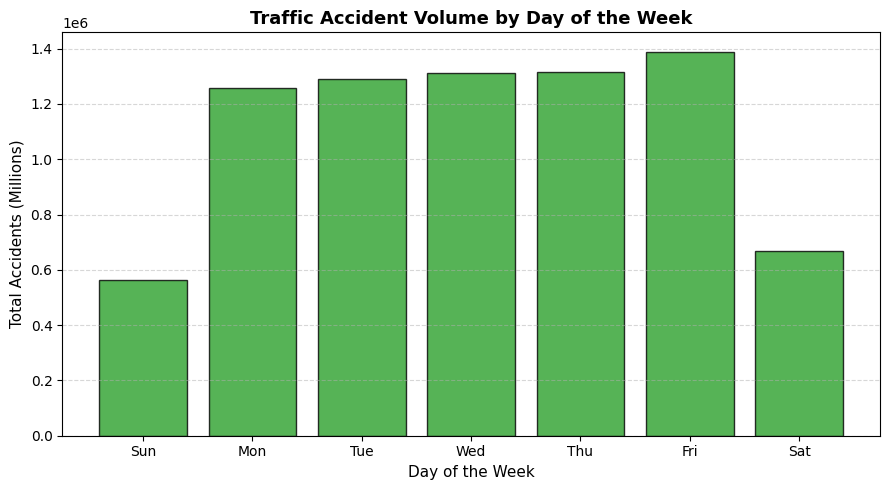

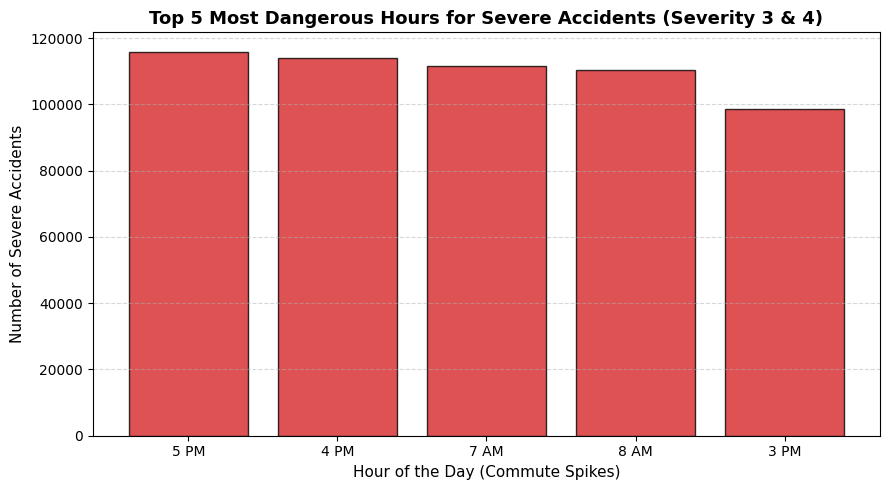

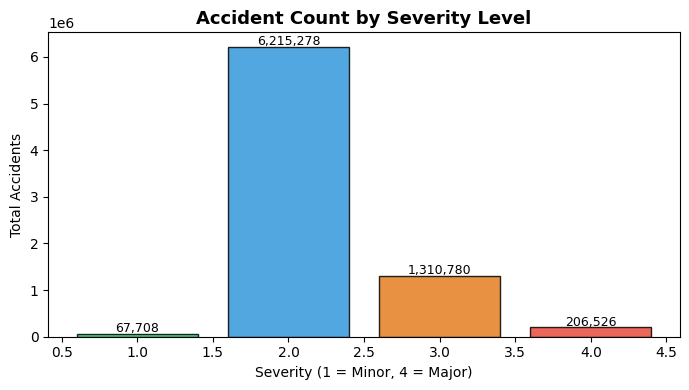

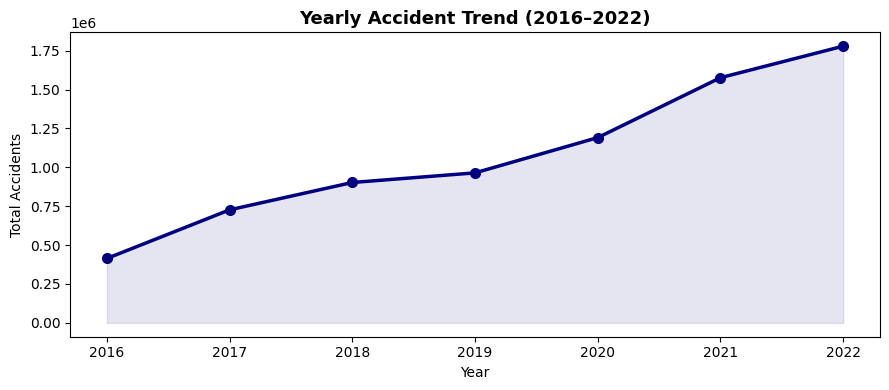

+-----------------------+---+-------+-----+---+
|Severity_prediction_int|  1|      2|    3|  4|
+-----------------------+---+-------+-----+---+
|                      1|151|  13263|  174|  0|
|                      2|  2|1225758|17478| 57|
|                      3|  5| 220125|42284| 95|
|                      4|  2|  39717| 1484|394|
+-----------------------+---+-------+-----+---+



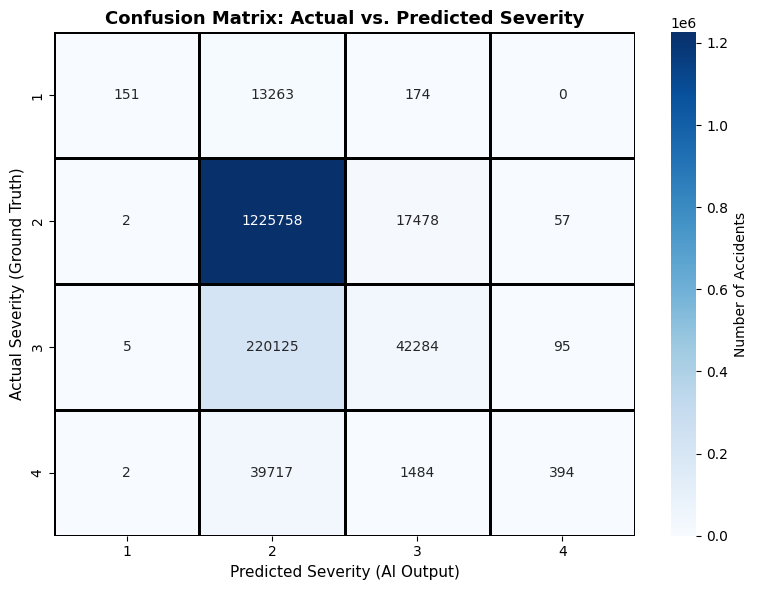

In [ ]:

# ==============================================================================
# SECTION 3: DATA VISUALIZATIONS (MATPLOTLIB)
# ==============================================================================
print("\nGenerating charts...")

# ------------------------------------------------------------------
# CHART 1: Total Accidents by Day of the Week
# ------------------------------------------------------------------
day_data = spark.sql("""
    SELECT DayOfWeek, COUNT(*) as Total_Accidents
    FROM accidents_gold
    GROUP BY DayOfWeek
    ORDER BY DayOfWeek
""").toPandas()

day_labels = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

plt.figure(figsize=(9, 5))
plt.bar(day_data['DayOfWeek'], day_data['Total_Accidents'], color='#2ca02c', edgecolor='black', alpha=0.8)
plt.title('Traffic Accident Volume by Day of the Week', fontsize=13, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=11)
plt.ylabel('Total Accidents (Millions)', fontsize=11)
plt.xticks(day_data['DayOfWeek'], day_labels)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("chart_accidents_by_day.png", dpi=150) # Save before showing
plt.show()


# ------------------------------------------------------------------
# CHART 2: Top 5 Most Dangerous Hours for Severe Accidents
# ------------------------------------------------------------------
hour_data = spark.sql("""
    SELECT Hour, COUNT(*) as Severe_Accidents
    FROM accidents_gold
    WHERE Severity IN (3, 4)
    GROUP BY Hour
    ORDER BY Severe_Accidents DESC
    LIMIT 5
""").toPandas()

# Map hour integers to readable time strings (e.g., 17 -> "5 PM")
time_labels = [f"{h-12} PM" if h > 12 else f"{h} AM" for h in hour_data['Hour']]

plt.figure(figsize=(9, 5))
plt.bar(time_labels, hour_data['Severe_Accidents'], color='#d62728', edgecolor='black', alpha=0.8)
plt.title('Top 5 Most Dangerous Hours for Severe Accidents (Severity 3 & 4)', fontsize=13, fontweight='bold')
plt.xlabel('Hour of the Day (Commute Spikes)', fontsize=11)
plt.ylabel('Number of Severe Accidents', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("chart_dangerous_hours.png", dpi=150)
plt.show()


# ------------------------------------------------------------------
# CHART 3: Accident Count by Severity Level
# ------------------------------------------------------------------
sev_data = spark.sql("""
    SELECT Severity, COUNT(*) as count
    FROM accidents_gold
    GROUP BY Severity
    ORDER BY Severity
""").toPandas()

plt.figure(figsize=(7, 4))
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
bars = plt.bar(sev_data['Severity'], sev_data['count'], color=colors, edgecolor='black', alpha=0.85)
plt.title('Accident Count by Severity Level', fontsize=13, fontweight='bold')
plt.xlabel('Severity (1 = Minor, 4 = Major)')
plt.ylabel('Total Accidents')

# Add numeric labels on top of each bar
for bar, val in zip(bars, sev_data['count']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30000,
             f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("chart_severity_dist.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# CHART 4: Yearly Accident Trend
# ------------------------------------------------------------------
yearly_data = spark.sql("""
    SELECT Year, COUNT(*) as Total FROM accidents_gold
    WHERE Year < 2023
    GROUP BY Year ORDER BY Year
""").toPandas()

plt.figure(figsize=(9, 4))
plt.plot(yearly_data['Year'], yearly_data['Total'], marker='o', linewidth=2.5, color='navy', markersize=7)
plt.fill_between(yearly_data['Year'], yearly_data['Total'], alpha=0.1, color='navy')
plt.title('Yearly Accident Trend (2016–2022)', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Accidents')
plt.xticks(yearly_data['Year'])
plt.tight_layout()
plt.savefig("chart_yearly_trend.png", dpi=150)
plt.show()

# ==============================================================================
# CHART 5: CONFUSION MATRIX (Satisfying Reviewer Point #4)
# ==============================================================================
import seaborn as sns
from pyspark.sql.functions import col

# 1. First, print a simple text-based table directly from Spark

# Cast 'prediction' to integer to align with 'Severity' type before crosstab
conf_matrix_spark = predictions.withColumn("prediction_int", col("prediction").cast("integer")).crosstab("Severity", "prediction_int").orderBy("Severity_prediction_int")
conf_matrix_spark.show()

# 2. Aggregate the prediction counts safely in Spark, then send to Pandas
cm_data = predictions.withColumn("prediction_int", col("prediction").cast("integer")).groupBy("Severity", "prediction_int").count().toPandas()

# 3. Pivot the table so 'Actual Severity' are rows and 'Predicted Severity' are columns
cm_pivot = cm_data.pivot(index='Severity', columns='prediction_int', values='count').fillna(0)

# 4. Draw the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_pivot, annot=True, fmt=".0f", cmap="Blues",
            linewidths=1, linecolor='black', cbar_kws={'label': 'Number of Accidents'})

plt.title("Confusion Matrix: Actual vs. Predicted Severity", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Severity (AI Output)", fontsize=11)
plt.ylabel("Actual Severity (Ground Truth)", fontsize=11)
plt.tight_layout()

# Save for your report!
plt.savefig("chart_confusion_matrix.png", dpi=150)
plt.show()